In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import numpy as np
from PIL import Image
from tempfile import TemporaryDirectory

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(device)
cudnn.benchmark = True
plt.ion()   # interactive mode

cuda


In [12]:
# Aggregating datasets
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'training': transforms.Compose([
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'image_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['training', 'test']}
dataloaders = {x: data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['training', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['training', 'test']}
class_names = image_datasets['training'].classes
print(class_names)

['autotuned', 'original']


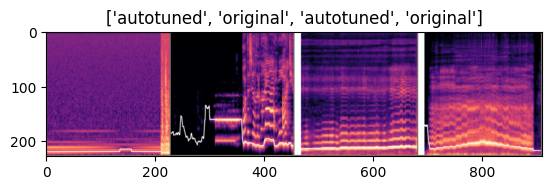

In [13]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['training']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [14]:
def train_model(model, criterion, optimizer, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['training', 'test']:
                if phase == 'training':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'training'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'training':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                #if phase == 'training':

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'test' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

In [15]:
model = models.resnet50(pretrained=True)
#for param in model.parameters():
#    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
#lr_schedule = optim.lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=5)

model_conv = train_model(model, criterion, optimizer, num_epochs=25)

Epoch 0/24
----------
training Loss: 0.6963 Acc: 0.5295
test Loss: 3.3275 Acc: 0.5183

Epoch 1/24
----------
training Loss: 0.6947 Acc: 0.4990
test Loss: 0.7023 Acc: 0.4987

Epoch 2/24
----------
training Loss: 0.6955 Acc: 0.4989
test Loss: 0.7612 Acc: 0.4780

Epoch 3/24
----------
training Loss: 0.6935 Acc: 0.5162
test Loss: 0.7122 Acc: 0.4958

Epoch 4/24
----------
training Loss: 0.6841 Acc: 0.5454
test Loss: 0.6947 Acc: 0.5201

Epoch 5/24
----------
training Loss: 0.5771 Acc: 0.6812
test Loss: 0.6778 Acc: 0.6001

Epoch 6/24
----------
training Loss: 0.4618 Acc: 0.7502
test Loss: 0.6126 Acc: 0.6475

Epoch 7/24
----------
training Loss: 0.3786 Acc: 0.7992
test Loss: 0.5460 Acc: 0.7027

Epoch 8/24
----------
training Loss: 0.3175 Acc: 0.8361
test Loss: 0.6232 Acc: 0.6959

Epoch 9/24
----------
training Loss: 0.2883 Acc: 0.8494
test Loss: 0.4741 Acc: 0.7431

Epoch 10/24
----------
training Loss: 0.2656 Acc: 0.8635
test Loss: 0.4340 Acc: 0.7593

Epoch 11/24
----------
training Loss: 0.25

In [ ]:
model_conv = train_model(model, criterion, optimizer, num_epochs=25)